### This notebook reproduces the classic results from Binney 2019 https://arxiv.org/abs/1906.11696. The code directly uses our star-gas formalism and is therefore a good consistency check.

In [9]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np

import smplotlib 

# Change this to your source directory.

codedir = "../src/"

sys.path.append(os.path.abspath(codedir))

from Vlasov_integrators_thick_disk import *


# Figure 3

In [10]:
def get_Sigma_s_and_sigma_x_from_Q_and_krcit(Q, kcrit, kappa = 1, G =1):
    
    Sigma_s = kappa*kappa/(2*np.pi*kcrit*G) # Eq. (18) of Binney 2019
    sigma_x = 1.0/ (kappa/(3.36*Q*G*Sigma_s)) # Eq. (19) of Binney 2019

    return Sigma_s, sigma_x

In [11]:
kappa_val = 1.0
tf = 5*np.pi/kappa_val
kxval = 0.0
Q = 1
kcrit = 1
G = 1
Omega0_val = kappa_val/np.sqrt(2)
Sigma_s_val, sigma_x_val = get_Sigma_s_and_sigma_x_from_Q_and_krcit(Q,kcrit)

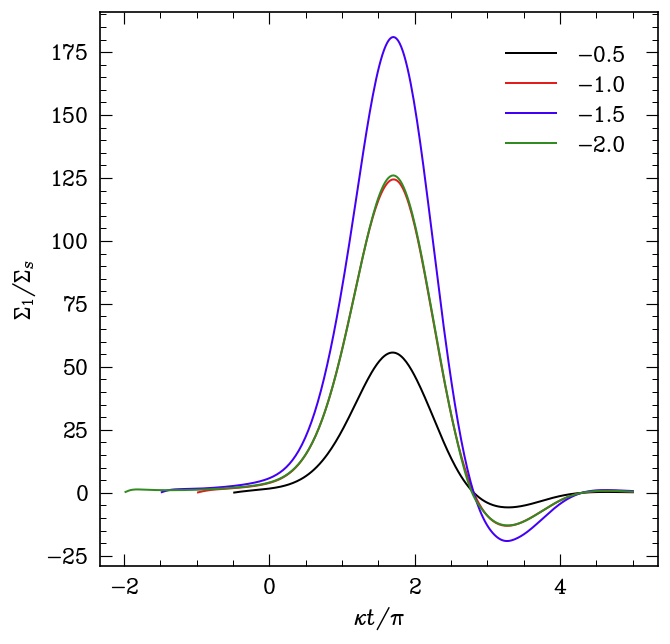

In [12]:
sim = Gas_plus_stars_integrator(
    kx=kxval, kyc=kcrit, Sigma_s= Sigma_s_val, Sigma_g = 0.0,
    kappa= kappa_val, Omega0= Omega0_val, sigma_x = sigma_x_val, cssq = 0.0, Hg = 0.0, Hs = 0.0, G= 1)


for ti in np.array([-0.5, -1.0, -1.5, -2.]):

    t_grid = np.linspace(ti*np.pi/kappa_val, tf, 301)
    results = sim.solve(t_grid, fext_params={'delta': 0.0, 'amplitude' : 0}, impulse_params = {"t_0": ti*np.pi/kappa_val, "Sigma_impluse" : 1})

    surface_densities_stellar = sim.get_stellar_surface_density(results, t_grid)

    plt.plot(kappa_val*t_grid[1:]/np.pi, surface_densities_stellar, label = ti )

plt.ylabel(r'$\Sigma_1/\Sigma_s$')
plt.xlabel(r'$\kappa t/\pi$')
plt.legend()

# Figure 4

In [13]:
kappa_val = 1.0
tf = 5*np.pi/kappa_val
kxval = 0.0
kcrit = 1
G = 1
ti = -3.0*np.pi/2.0/kappa_val
Omega0_val = kappa_val/np.sqrt(2)

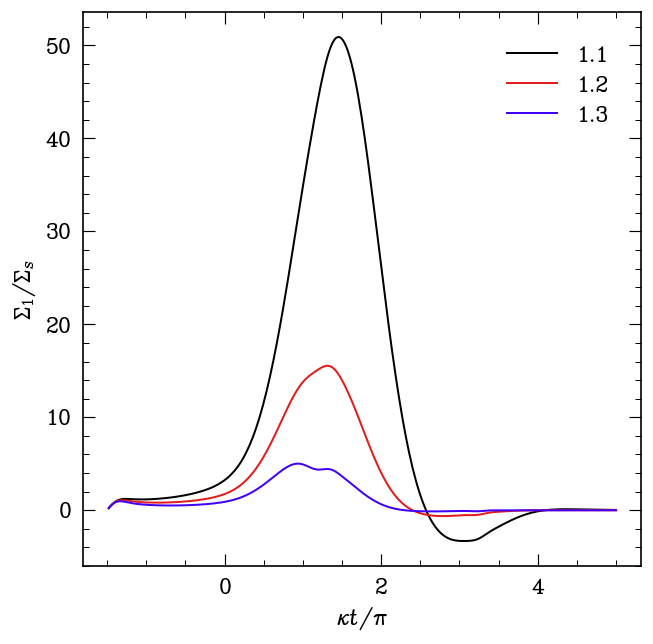

In [17]:
for Q in [1.1, 1.2, 1.3]:
    Sigma_s_val, sigma_x_val = get_Sigma_s_and_sigma_x_from_Q_and_krcit(Q,kcrit)

    sim = Gas_plus_stars_integrator(
    kx=kxval, kyc=kcrit, Sigma_s= Sigma_s_val, Sigma_g = 0.0,
    kappa= kappa_val, Omega0= Omega0_val, sigma_x = sigma_x_val, cssq = 0.0, Hg = 0.0, Hs = 0.0, G= 1)


    t_grid = np.linspace(ti, tf, 301)
    results = sim.solve(t_grid, fext_params={'delta': 0.0, 'amplitude' : 0}, impulse_params = {"t_0": ti, "Sigma_impluse" : 1})

    surface_densities_stellar = sim.get_stellar_surface_density(results, t_grid)

    plt.plot(kappa_val*t_grid[1:]/np.pi, surface_densities_stellar, label = Q )

plt.ylabel(r'$\Sigma_1/\Sigma_s$')
plt.xlabel(r'$\kappa t/\pi$')
plt.legend()

# Figure 6

In [18]:
kappa_val = 1.0
kxval = 0.0
kcrit = 1
G = 1
Omega0_val = kappa_val/np.sqrt(2)

In [19]:
from numba import njit

In [20]:
def Kfunc_kernel(t,ti, kyval, Q):
    Sigma_s_val, sigma_x_val = get_Sigma_s_and_sigma_x_from_Q_and_krcit(Q,1)
    return njit_K_kernel_func(t, ti, kxval, kyval, Sigma_s_val, kappa_val, Omega0_val, sigma_x_val, 0.0, G)


def Kfunc_kernel_max(tf,ti, kyval, Q, nvals = 500):
    tgrid= np.linspace(ti,tf, nvals)

    Kvals = np.array([Kfunc_kernel(t,ti,kyval,Q) for t in tgrid])

    return float(np.max(Kvals))



def get_self_gravity_response_max(tf,ti, kyval,Q, nvals = 500):
    Sigma_s_val, sigma_x_val = get_Sigma_s_and_sigma_x_from_Q_and_krcit(Q,1)
    sim = Gas_plus_stars_integrator(
    kx=kxval, kyc=kyval, Sigma_s= Sigma_s_val, Sigma_g = 0.0,
    kappa= kappa_val, Omega0= Omega0_val, sigma_x = sigma_x_val, cssq = 0.0, Hg = 0.0, Hs = 0.0, G= 1)
    

    t_grid = np.linspace(ti, tf, nvals)
    results = sim.solve(t_grid, fext_params={'delta': 0.0, 'amplitude' : 0}, impulse_params = {"t_0": ti, "Sigma_impluse" : 1})

    surface_densities_stellar = sim.get_stellar_surface_density(results, t_grid)

    return np.max(surface_densities_stellar)

In [21]:
kcritvals = np.linspace(0.2,5,100) # Increase number of points for better resolution
tivals = np.linspace(-20,15,50) # Increase number of points for better resolution

In [22]:
import time

In [23]:
plotting_arr = []
Qs = [1.2, 1.3, 1.4, 1.5, 1.6, 1.8, 2]
for Q in Qs:
    start = time.perf_counter()
    maxvals = []
    for j in range(len(kcritvals)):
        maximum = 0.0
        for ti in tivals:
            num = get_self_gravity_response_max(20,ti, kcritvals[j], Q, 100)
            denum = Kfunc_kernel_max(20, ti, kcritvals[j], Q, 100)
            maximum = max(maximum,  num/denum) 
            
        maxvals.append(maximum)

    plotting_arr.append([Q, maxvals])

    end = time.perf_counter()

    print(f"Elapsed time: {end - start:.6f} seconds")

Elapsed time: 5.524826 seconds
Elapsed time: 4.793252 seconds
Elapsed time: 4.812557 seconds
Elapsed time: 4.776882 seconds
Elapsed time: 4.779245 seconds
Elapsed time: 4.767404 seconds
Elapsed time: 4.769349 seconds


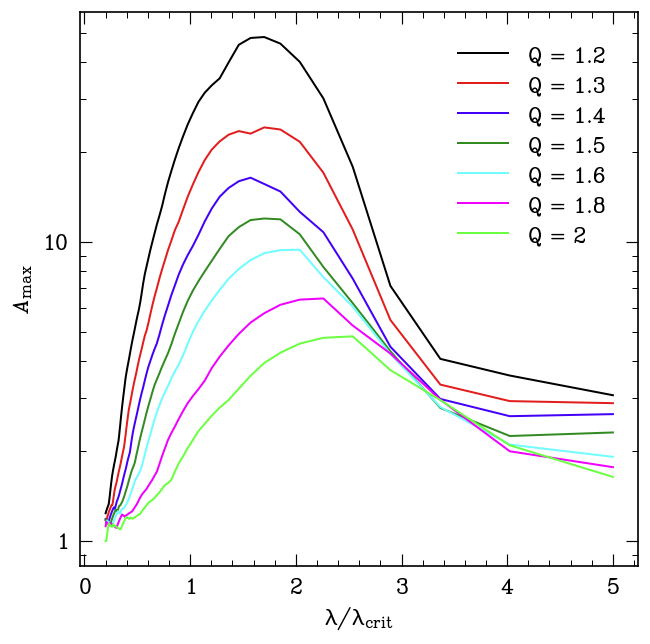

In [24]:
for j in range(len(Qs)):
    plt.plot(1/kcritvals, np.array(plotting_arr[j][1]), label = 'Q = {}'.format(Qs[j]))

plt.legend()
plt.ylabel(r'$A_{\mathrm{max}}$')
plt.xlabel(r'$\lambda/\lambda_{\mathrm{crit}}$')
plt.yscale('log')